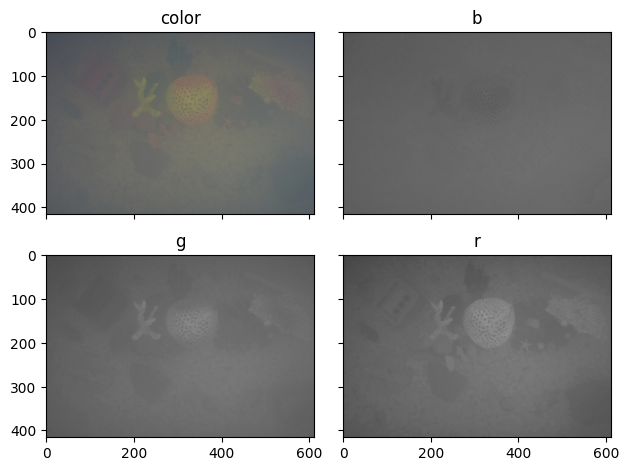

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass

from pathlib import Path

from common import OrderedImage, FloatArray, Uint8Array
from plotting import plot_imgs, plot_img, plot_channels
from main import StatType, MinMaxMean, Stats, load_img, color_loss, channel_correction, basic_CLAHE_float, basic_CLAHE_u8_cl
from clahe import tclahe

PATH = Path('milk') / '15.jpg'
# PATH = Path('lake') / 'blue_blur.png'
# PATH = Path('cup') / '0.png'
# PATH = Path('deepblue') / '8.jpg'

img = load_img(PATH)
plot_channels(img)

og_img = img.clone()

# B. Dynamic Turbid Color Correction

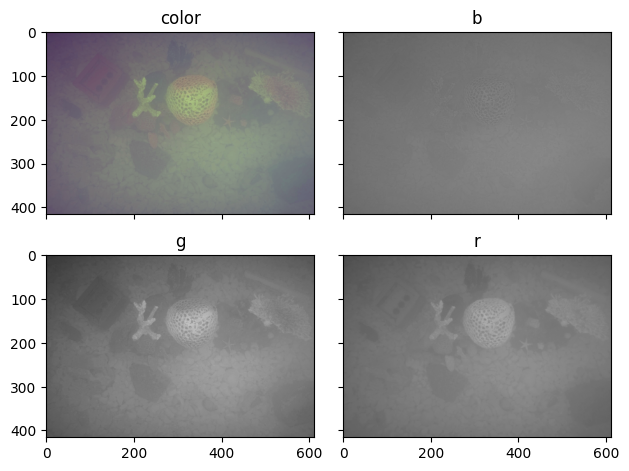

In [3]:
def plot_hist(channel_0_1, title):
    plt.title(f'{title} ({channel_0_1.min(), channel_0_1.max()})')
    plt.plot(cv2.calcHist([(channel_0_1 * 255).astype(np.uint8)], channels=[0], mask=None, histSize=[256], ranges=[0, 256]))
    plt.show()


def plot_hists(img: OrderedImage[FloatArray], suptitle):
    subtitles = ('b', 'g', 'r')
    fig, axs = plt.subplots(nrows=1, ncols=3, sharex=True, sharey=True)
    fig.suptitle(suptitle)
    for i, ax in enumerate(axs.flat):
        ax.plot(cv2.calcHist([(img.cf[i] * 255).astype(np.uint8)], channels=[0], mask=None, histSize=[256], ranges=[0, 256]))
        ax.title.set_text(subtitles[i])
    fig.tight_layout()
    fig.set_size_inches(10, 5)
    plt.show()

# plot_hists(img, 'uncorrected')

channel_correction(img)

# plot_hists(img, 'corrected')

plot_channels(img)

# C. Advanced De-Turbid Scene Model

## Using OpenCV (static clip limit)

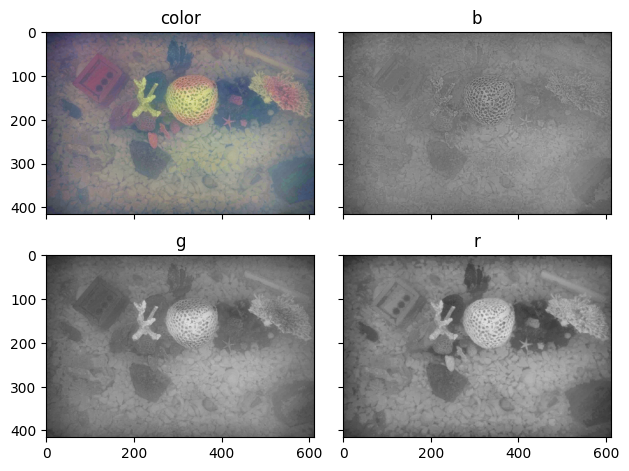

In [4]:
clahed_static = basic_CLAHE_float(img)
plot_channels(clahed_static)
# plot_img(np.hstack((img.cl, clahed_static.cl)))

## Dynamic Clip Limit

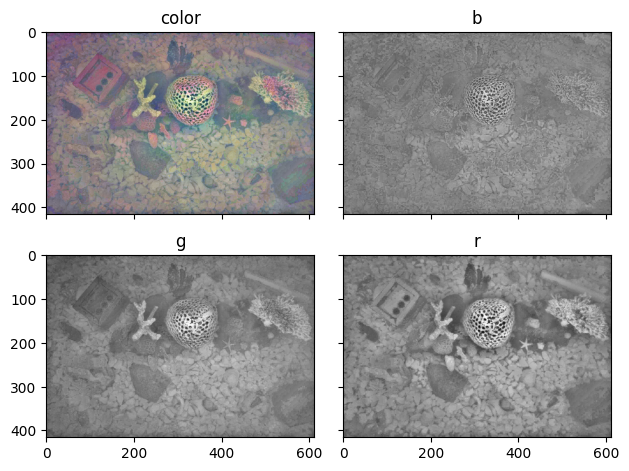

In [5]:
clahed_dynamic = tclahe(img, n=32, interpolate=True)
plot_channels(clahed_dynamic)

# clahed_dynamic_uninterpolated = tclahe(img, n=16, interpolate=False)
# plot_channels(clahed_dynamic_uninterpolated)

# plot_imgs([img, clahed_static, clahed_dynamic_uninterpolated, clahed_dynamic],
#           titles=['Only color corrected', 'Naive CLAHE', 'Uninterpolated Turbidity-\nAware CLAHE', '\nInterpolated Turbidity-\nAware CLAHE'])

# Evaluation

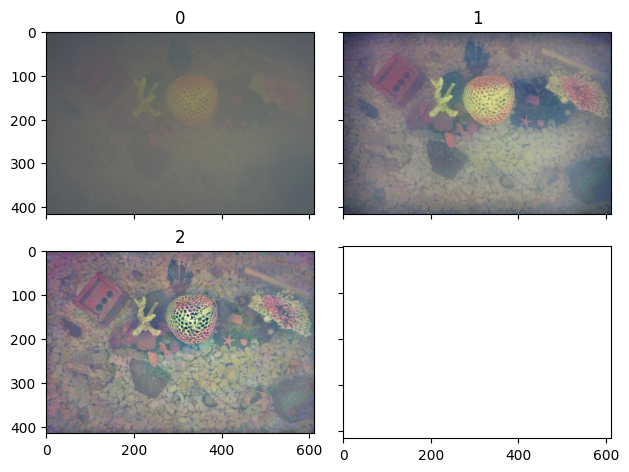

5.5376463 14.717467 12.804957


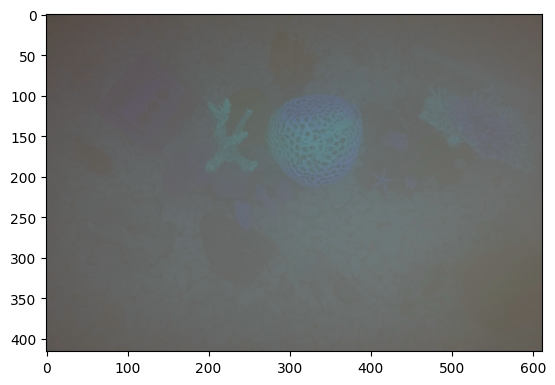

In [6]:
from metrics import uciqe

plot_imgs((og_img, clahed_static, clahed_dynamic))

print(uciqe(og_img), uciqe(clahed_static), uciqe(clahed_dynamic))

plt.imshow(og_img.cl)
# cv2.imshow('clahe', clahed_dynamic.cl)